# Assignment Sesi 19
Nama: Faraday Barr Fatahillah

**INSTRUKSI**\
Anda adalah data scientist di sebuah perusahaan healthtech. Tim klinis meminta model prediksi risiko penyakit jantung yang bisa diandalkan secara akurasi dan bisa dijelaskan kepada dokter. Anda diminta menyajikan tiga kandidat model beserta perbandingannya.

Dataset: https://www.kaggle.com/datasets/cherngs/heart-disease-cleveland-uci \
**Dataset sudah tidak available jadi pakai yang mirip dengan reference dari notebook [ini](https://www.kaggle.com/code/vbmokin/heart-disease-automatic-adveda-fe-20-models/notebook#2.-Download-datasets-)**

In [27]:
import time
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score
import matplotlib.pyplot as plt

**Task 1 — Decision Tree dan Feature Importance**
1. Load dataset, lakukan train-test split 80:20 dengan random_state=42.
2. Latih DecisionTreeClassifier dengan parameter default.
3. Visualisasikan tree hingga max_depth=3 menggunakan plot_tree dari sklearn.
4. Plot feature importance sebagai bar chart horizontal, urutkan dari terbesar ke terkecil.
5. Tulis interpretasi 3-4 kalimat: fitur apa yang paling menentukan, dan apakah hasil ini masuk akal secara medis?

In [28]:
#Task 1.1
df = pd.read_csv('heart_cleveland_upload.csv')

df.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0
5,64,1,0,170,227,0,2,155,0,0.6,1,0,2,0
6,63,1,0,145,233,1,2,150,0,2.3,2,0,1,0
7,61,1,0,134,234,0,0,145,0,2.6,1,2,0,1
8,60,0,0,150,240,0,0,171,0,0.9,0,0,0,0
9,59,1,0,178,270,0,2,145,0,4.2,2,0,2,0


Deskripsi fitur:
1. age: age in years
2. sex: sex (1 = male; 0 = female)
3. cp: chest pain type
    - Value 0: typical angina
    - Value 1: atypical angina
    - Value 2: non-anginal pain
    - Value 3: asymptomatic
4. trestbps: resting blood pressure (in mm Hg on admission to the hospital)
5. chol: serum cholestoral in mg/dl
6. fbs: (fasting blood sugar > 120 mg/dl) (1 = true; 0 = false)
7. restecg: resting electrocardiographic results
    - Value 0: normal
    - Value 1: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV)
    - Value 2: showing probable or definite left ventricular hypertrophy by Estes' criteria
8. thalach: maximum heart rate achieved
9. exang: exercise induced angina (1 = yes; 0 = no)
10. oldpeak = ST depression induced by exercise relative to rest
11. slope: the slope of the peak exercise ST segment
    - Value 0: upsloping
    - Value 1: flat
    - Value 2: downsloping
12. ca: number of major vessels (0-3) colored by flourosopy
13. thal: 0 = normal; 1 = fixed defect; 2 = reversable defect 
14. condition: 0 = no disease, 1 = disease (ini target)

In [29]:
for x in df.columns:
    print(f'{x}: {df[x].unique()}\n')

age: [69 66 65 64 63 61 60 59 58 56 52 51 45 42 40 38 34 74 71 70 62 57 55 54
 50 49 48 46 44 41 35 29 76 68 67 53 47 43 39 37 77]

sex: [1 0]

cp: [0 1 2 3]

trestbps: [160 140 150 138 110 170 145 134 178 120 118 152 125 148 156 128 136 130
 124 154 135 132 108 192 101 105 112 126 122 180 115 146 155 102 172 100
  94 129 142 144 106 117 158 174 164 114 165 200 123 104]

chol: [234 239 226 282 211 227 233 240 270 288 273 204 283 193 186 298 213 264
 244 199 231 182 269 302 245 246 195 281 208 221 284 319 236 261 232 294
 250 262 342 309 325 201 205 271 266 229 197 160 308 263 219 220 295 203
 198 235 306 157 192 210 265 254 274 277 564 212 278 417 360 335 313 252
 243 185 318 178 218 230 224 340 168 126 256 258 214 304 267 196 222 175
 188 149 275 255 257 253 177 141 242 315 209 180 268 321 215 174 322 286
 299 237 223 228 225 248 303 407 330 187 164 394 260 307 166 207 206 293
 305 326 249 176 216 259 300 276 289 241 131 354 184 409 217 353 327 200
 311 169 290 341 247 172 167 183]

f

In [30]:
df.isna().sum().sort_values(ascending=False)

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalach      0
exang        0
oldpeak      0
slope        0
ca           0
thal         0
condition    0
dtype: int64

In [31]:
X = df.drop(columns='condition')
y = df['condition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [32]:
#Task 1.2
clf_dtc = DecisionTreeClassifier()

clf_dtc.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

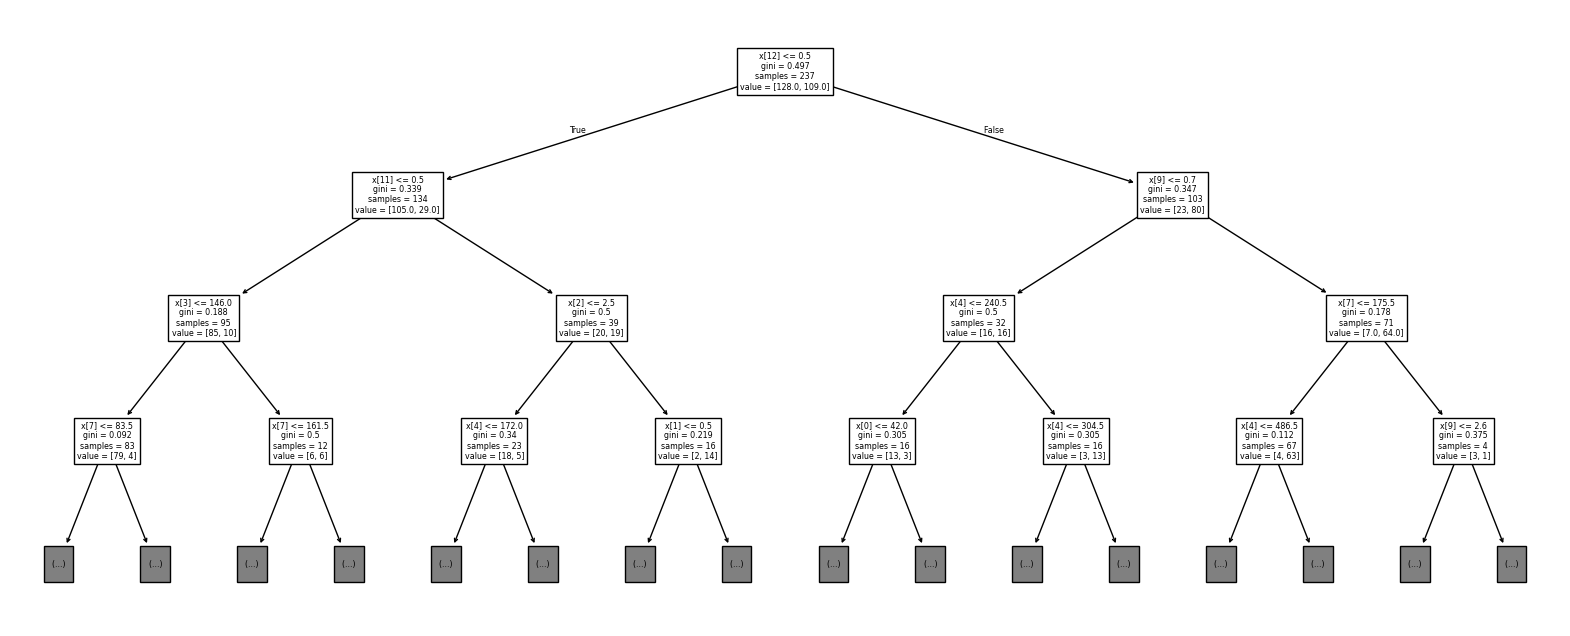

In [33]:
#Task 1.3
plt.figure(figsize=(20,8))
plot_tree(clf_dtc, max_depth=3)
plt.show()

In [34]:
#Task 1.4
feat_importance_dtc = clf_dtc.feature_importances_

df_importance_dtc = pd.DataFrame({
    'feature': X.columns,
    'importance': feat_importance_dtc
}).sort_values(by='importance', ascending=False).reset_index().drop(columns='index')

df_importance_dtc

,feature,importance
0,thal,0.319831
1,chol,0.142998
2,ca,0.088891
3,thalach,0.087291
4,age,0.086665
5,cp,0.077526
6,oldpeak,0.075882
7,trestbps,0.067126
8,sex,0.031142
9,fbs,0.011325


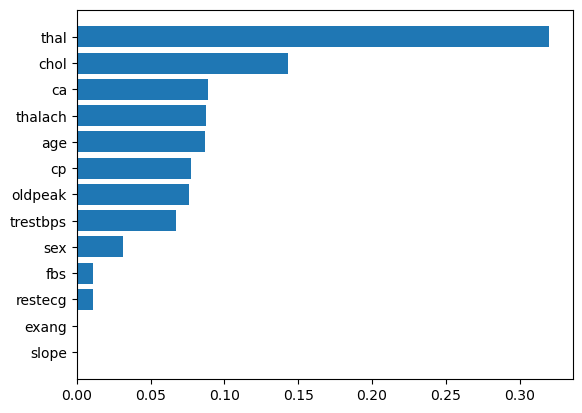

In [35]:
fig, ax = plt.subplots()

ax.barh(df_importance_dtc['feature'], df_importance_dtc['importance'], align='center')
ax.invert_yaxis()

plt.show()

**#Task 1.5**\
Dapat dilihat dari hasil decision tree di atas bahwa thal (blood flow) sangat berpengaruh terhadap penyakit jantung. Hal ini karena jantung memang yang memompa darah ke seluruh tubuh dan untuk melihat apakah jantung berfungsi dengan baik atau tidak, dilihat dari pattern pemompaan darahnya. Terdapat 3 kategori, yaitu normal, fixed defect, dan reversable defect, dimana normal, tentu saja normal, fixed defect merupakan genetik atau tidak ada perubahan saat olahraga, dan reversable defect yang merupakan cacat saat melakukan olahraga tetapi normal saat istirahat.

**Task 2 — Random Forest vs Decision Tree**
1. Latih RandomForestClassifier(n_estimators=100, random_state=42).
2. Bandingkan Decision Tree dan Random Forest menggunakan tabel: Accuracy, Precision, Recall, F1-score pada test set.
3. Plot feature importance Random Forest. Apakah urutan fiturnya berbeda dengan Decision Tree?
4. Jelaskan dalam 2-3 kalimat mengapa Random Forest cenderung menghasilkan performa lebih baik dari single Decision Tree.

In [36]:
#Task 2.1
clf_rfc = RandomForestClassifier(n_estimators=100, random_state=42)

clf_rfc.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [37]:
#Task 2.2
dtc_predict = clf_dtc.predict(X_test)
rfc_predict = clf_rfc.predict(X_test)

In [38]:
def get_metrics(y_test, y_pred):
    return {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1_score': f1_score(y_test, y_pred)
    }

dtc_metrics = get_metrics(y_test, dtc_predict)
rfc_metrics = get_metrics(y_test, rfc_predict)

metrics_name = ['accuracy', 'precision', 'recall', 'f1_score']

dt_vals = [dtc_metrics[m] for m in metrics_name]
rf_vals = [rfc_metrics[m] for m in metrics_name]

metrics_df = pd.DataFrame({
    'metrics': metrics_name,
    'dtc_val': dt_vals,
    'rfc_val': rf_vals 
})

metrics_df

,metrics,dtc_val,rfc_val
0,accuracy,0.716667,0.700000
1,precision,0.677419,0.666667
2,recall,0.750000,0.714286
3,f1_score,0.711864,0.689655


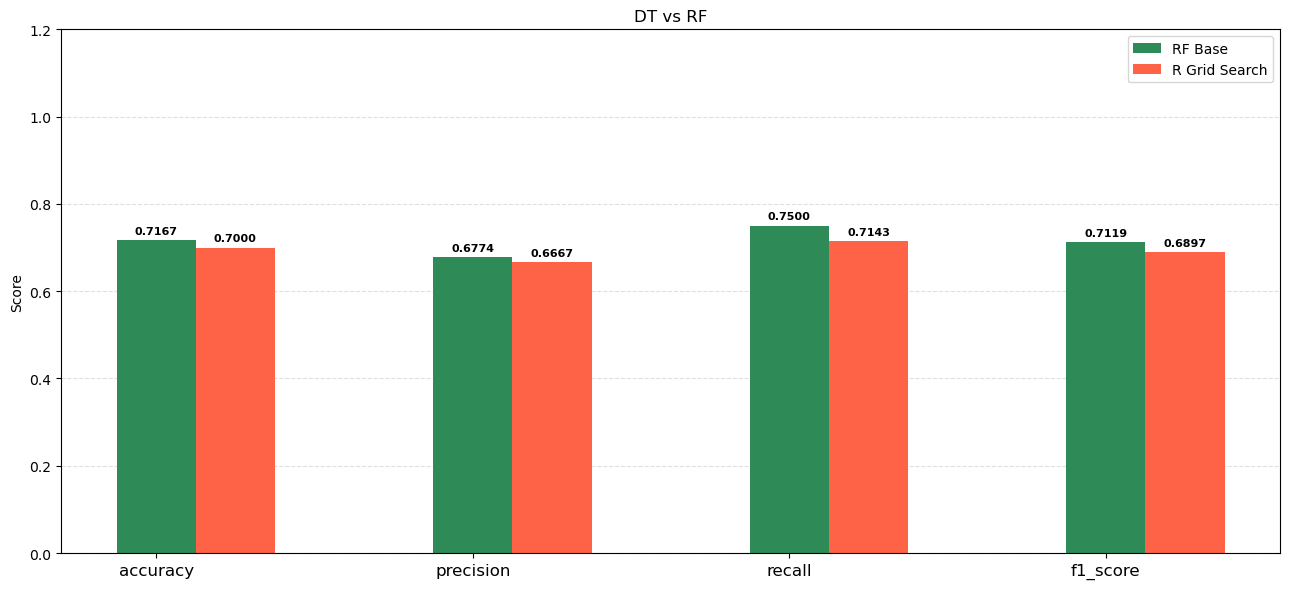

In [39]:
x = np.arange(len(metrics_df))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 6))

ax.bar(x, metrics_df['dtc_val'], width, label='RF Base', color='seagreen')
ax.bar(x + width, metrics_df['rfc_val'], width, label='R Grid Search', color='tomato')

for bars, col in zip(
    [ax.containers[0], ax.containers[1]],
    ['dtc_val', 'rfc_val']
):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                f'{h:.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metrics_df['metrics'], fontsize=12)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.2)
ax.set_title('DT vs RF')
ax.legend()
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

In [40]:
#Task 2.3
feat_importance_rfc = clf_rfc.feature_importances_

df_importance_rfc = pd.DataFrame({
    'feature': X.columns,
    'importance': feat_importance_rfc
}).sort_values(by='importance', ascending=False).reset_index().drop(columns='index')

df_importance_rfc

,feature,importance
0,thalach,0.156680
1,thal,0.127474
2,ca,0.105689
3,oldpeak,0.101429
4,cp,0.091788
5,age,0.091747
6,trestbps,0.088783
7,chol,0.080537
8,sex,0.044395
9,slope,0.042376


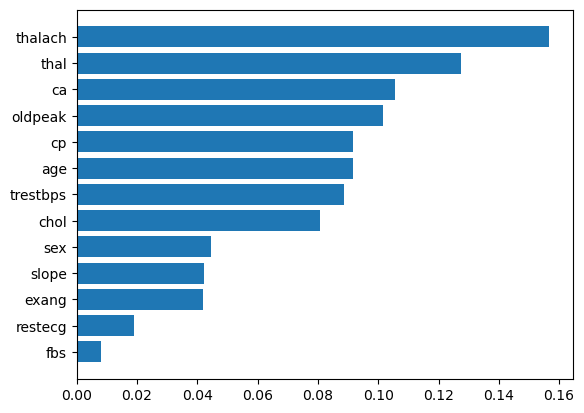

In [41]:
fig, ax = plt.subplots()

ax.barh(df_importance_rfc['feature'], df_importance_rfc['importance'], align='center')
ax.invert_yaxis()

plt.show()

**#Task 2.4**\
Masih inline dengan sebelumnya, tetapi ini menggunakan angkanya (thalach merupakan maximum heart rate selama olahraga). Semakin tinggi heart ratenya semakin lemah juga jantungnya karena harus bekerja lebih keras untuk memompa jumlah darah yang sama. Selain itu, thal menjadi fitur kedua yang terpenting saat menggunakan Random Forest, sehingga hasil masih mirip dengan Decision Tree. 

**Task 3 — Hyperparameter Tuning dengan GridSearchCV**

1. Tentukan grid pencarian untuk RandomForestClassifier dengan parameter berikut:
    ```
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 5, 10],
        'min_samples_split': [2, 5],
    }
    ```
2. Jalankan GridSearchCV dengan cv=5 dan scoring='f1'.
3. Cetak kombinasi parameter terbaik dan nilai F1 terbaik dari cross-validation.
4. Evaluasi model terbaik pada test set, bandingkan dengan Random Forest default dari Task 2.

In [42]:
#Task 3.1
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2,5]
}

new_clf_rfc = RandomForestClassifier()

In [43]:
grid_search = GridSearchCV(new_clf_rfc, param_grid=param_grid, cv=5, scoring='f1')

grid_search

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 5, ...], 'min_samples_split': [2, 5], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the sc

In [44]:
#Task 3.3
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 5, ...], 'min_samples_split': [2, 5], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the sc

In [45]:
gsc_predict = grid_search.predict(X_test)

gsc_metrics = get_metrics(y_test, gsc_predict)

gsc_vals = [gsc_metrics[m] for m in metrics_name]

metrics_df['gsc_val'] = gsc_vals

metrics_df

,metrics,dtc_val,rfc_val,gsc_val
0,accuracy,0.716667,0.700000,0.750000
1,precision,0.677419,0.666667,0.724138
2,recall,0.750000,0.714286,0.750000
3,f1_score,0.711864,0.689655,0.736842


In [46]:
print('Best Parameters:', grid_search.best_params_)
print('Best CV F1 Score:', round(grid_search.best_score_, 4))

Best Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
Best CV F1 Score: 0.8575


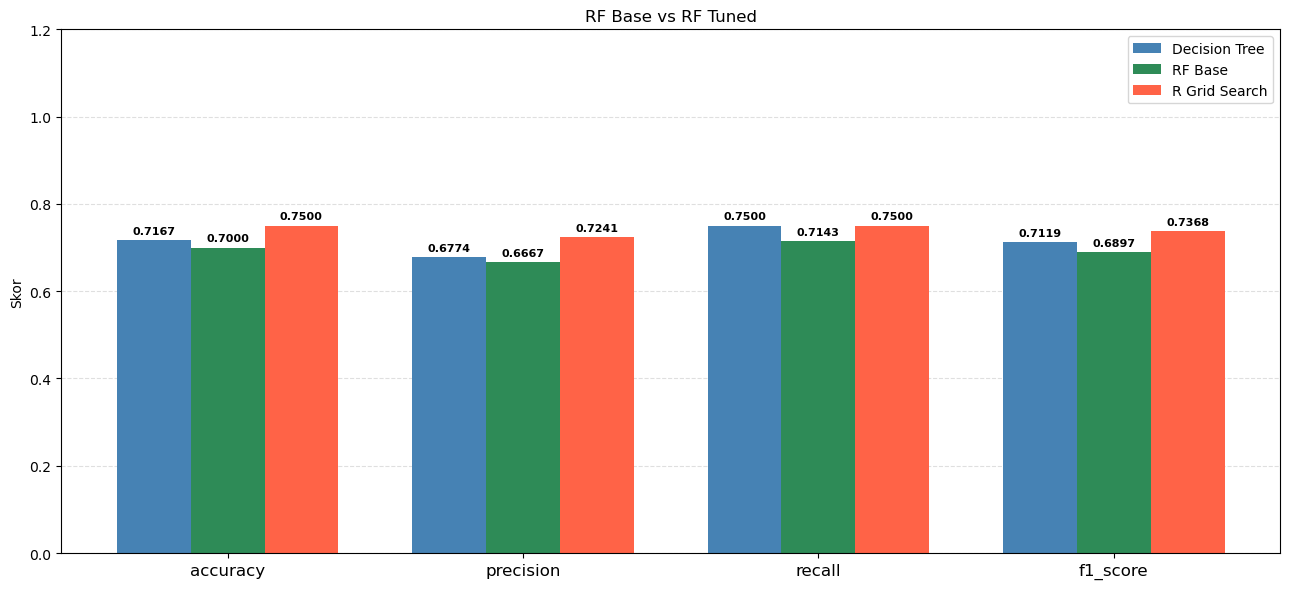

In [47]:
#Task 3.4
x = np.arange(len(metrics_df))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 6))

ax.bar(x - width, metrics_df['dtc_val'], width, label='Decision Tree', color='steelblue')
ax.bar(x, metrics_df['rfc_val'], width, label='RF Base', color='seagreen')
ax.bar(x + width, metrics_df['gsc_val'], width, label='R Grid Search', color='tomato')

for bars, col in zip(
    [ax.containers[0], ax.containers[1], ax.containers[2]],
    ['dtc_val', 'rfc_val', 'gsc_val']
):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                f'{h:.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metrics_df['metrics'], fontsize=12)
ax.set_ylabel('Skor')
ax.set_ylim(0, 1.2)
ax.set_title('RF Base vs RF Tuned')
ax.legend()
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

**Task 4 — Gradient Boosting (Opsional untuk yang sudah selesai Task 1-3)**
1. Latih GradientBoostingClassifier dengan parameter default.
2. Masukkan hasilnya ke tabel perbandingan Task 2.
3. Catat waktu training Gradient Boosting vs Random Forest menggunakan time.time(). Berikan komentar: kapan Gradient Boosting lebih masuk akal dipilih

In [48]:
start_rf = time.time()
clf_rfc.fit(X_train, y_train)
end_rf = time.time()

gb = GradientBoostingClassifier(random_state=42)
start_gb = time.time()
gb.fit(X_train, y_train)
end_gb = time.time()

rf_time = end_rf - start_rf
gb_time = end_gb - start_gb

print(f"Random Forest waktu: {rf_time:.4f} detik")
print(f"Gradient Boosting waktu: {gb_time:.4f} detik")

Random Forest waktu: 0.0820 detik
Gradient Boosting waktu: 0.0622 detik


In [49]:
gb_predict = gb.predict(X_test)

In [50]:
gb_metrics = get_metrics(y_test, gb_predict)

gb_vals = [gb_metrics[m] for m in metrics_name]

metrics_df['gb_val'] = gb_vals

metrics_df

,metrics,dtc_val,rfc_val,gsc_val,gb_val
0,accuracy,0.716667,0.700000,0.750000,0.733333
1,precision,0.677419,0.666667,0.724138,0.700000
2,recall,0.750000,0.714286,0.750000,0.750000
3,f1_score,0.711864,0.689655,0.736842,0.724138


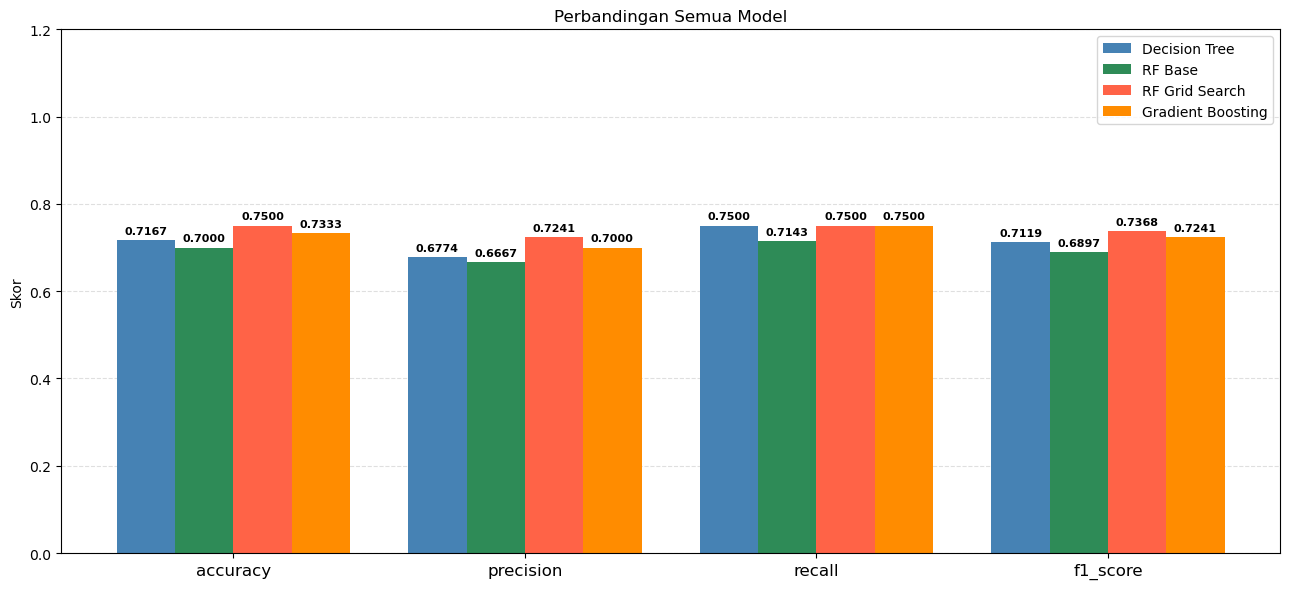

In [52]:
x = np.arange(len(metrics_df))
width = 0.2

fig, ax = plt.subplots(figsize=(13, 6))

ax.bar(x - 1.5*width, metrics_df['dtc_val'], width, label='Decision Tree', color='steelblue')
ax.bar(x - 0.5*width, metrics_df['rfc_val'], width, label='RF Base', color='seagreen')
ax.bar(x + 0.5*width, metrics_df['gsc_val'], width, label='RF Grid Search', color='tomato')
ax.bar(x + 1.5*width, metrics_df['gb_val'], width, label='Gradient Boosting', color='darkorange')


for bars, col in zip(
    [ax.containers[0], ax.containers[1], ax.containers[2], ax.containers[3]],
    ['dtc_val', 'rfc_val', 'gsc_val', 'gb_val']
):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                f'{h:.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metrics_df['metrics'], fontsize=12)
ax.set_ylabel('Skor')
ax.set_ylim(0, 1.2)
ax.set_title('Perbandingan Semua Model')
ax.legend()
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('hasil_ML_assignment_sesi_19.png')
plt.show()

**Task 4.3**\
Melihat hasil ini, salah satu yang dapat dideduksi adalah dataset yang kecil membuat Gradient Boosting menjadi lebih bagus daripada Random Forest. Hal ini karena, kalau tidak salah, Random Forest itu melakukan training dalam bentuk paralel sehingga cepat. Sedangkan Gradient Boosting lebih mementingkan akurasi tetapi membutuhkan waktu yang lebih lama.